# EMD-Based Schizophrenia Classification on Dataset 1 using Alpha-Band Connectivity Features

## Objectives

The objectives of this notebook are:

- load EEG recordings from Dataset 1
- segment each recording into overlapping 5-second windows
- apply EMD to each EEG channel
- retain IMFs whose dominant frequency lies in the alpha band
- compute instantaneous phases using the Hilbert transform
- extract connectivity features based on PLV and PLI
- train and evaluate machine learning classifiers for schizophrenia detection

In [ ]:
import mne
from glob import glob
import numpy as np
from PyEMD import EMD
from scipy.signal import butter,welch, hilbert, filtfilt
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# Charger les données EEG
def load_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    data = raw.get_data()  # Retourne le signal brut 
    fs = raw.info['sfreq']
    return data, fs

In [ ]:

# Découpage des signaux en segments
def segment_signal(signal, window_size, overlap):
    step = int(window_size * (1 - overlap))
    return [signal[:, i:i + window_size] for i in range(0, signal.shape[1] - window_size + 1, step)]


In [ ]:
healthy_file_paths = sorted(glob("dataverse_files/h*.edf"))[:2]
schizo_file_paths = sorted(glob("dataverse_files/s*.edf"))[:2]

healthy_data = [load_eeg(file) for file in healthy_file_paths]
schizo_data = [load_eeg(file) for file in schizo_file_paths]

Extracting EDF parameters from /content/dataverse_files/h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/s01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 211249  =      0.000 ...   844.996 secs...
Extracting EDF parameters from /content/dataverse_files/s02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 286249  =      0.000 ...  1144.996 secs...


## Exploratory Connectivity Visualization

Before building the classification pipeline, we explore average connectivity patterns in both groups using PLV and PLI adjacency matrices across the main EEG frequency bands:

- delta
- theta
- alpha
- beta
- gamma

This exploratory step helps visually assess how synchronization patterns differ between healthy subjects and schizophrenia patients.

### PLV Connectivity Maps

Phase Locking Value (PLV) measures how stable the phase difference remains between two EEG signals over time.

Higher PLV values indicate stronger phase synchronization between channels.

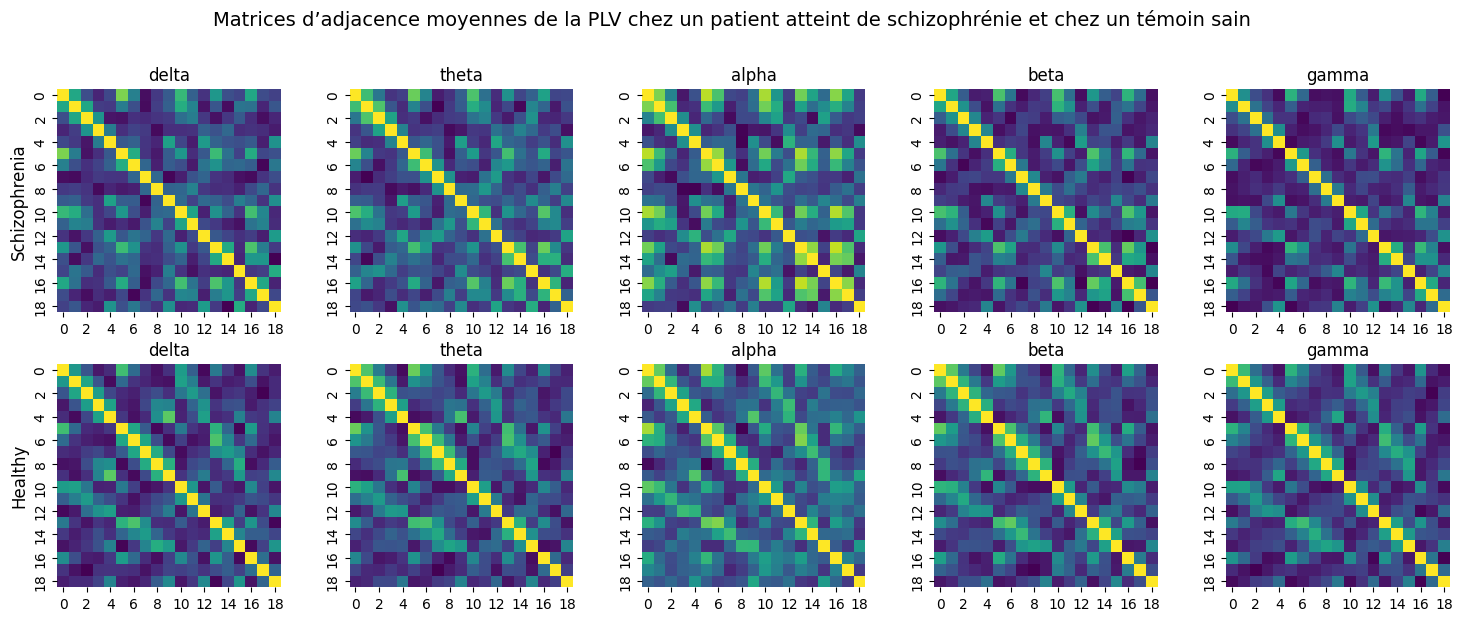

In [ ]:

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

def bandpass_filter(signal, fs, lowcut, highcut):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(4, [low, high], btype="band")
    return filtfilt(b, a, signal)

def compute_phases(filtered_signal):
    analytic_signal = hilbert(filtered_signal, axis=1)
    return np.angle(analytic_signal)

def compute_plv(phases):
    n_channels, n_times = phases.shape
    plv_matrix = np.zeros((n_channels, n_channels))
    for ch1 in range(n_channels):
        for ch2 in range(n_channels):
            phase_diff = phases[ch1, :] - phases[ch2, :]
            plv_matrix[ch1, ch2] = np.abs(np.mean(np.exp(1j * phase_diff)))
    return plv_matrix

def process_and_plot_plv(signals, fs, group_label, ax):
    for col, (band_name, (lowcut, highcut)) in enumerate(BANDS.items()):
        filtered_signals = [
            np.array([bandpass_filter(signal[ch, :], fs, lowcut, highcut)
                      for ch in range(signal.shape[0])])
            for signal in signals
        ]

        plv_group = np.mean(
            [compute_plv(compute_phases(filtered_signal)) for filtered_signal in filtered_signals],
            axis=0
        )

        sns.heatmap(plv_group, cmap="viridis", square=True, cbar=False, ax=ax[col])
        ax[col].set_title(f"{band_name}")
        if col == 0:
            ax[col].set_ylabel(group_label, fontsize=12)



fs = healthy_data[0][1]
healthy_signals = [data[0] for data in healthy_data]
schizo_signals = [data[0] for data in schizo_data]

fig, axes = plt.subplots(2, len(BANDS), figsize=(15, 6))


process_and_plot_plv(schizo_signals, fs, "Schizophrenia", axes[0, :])


process_and_plot_plv(healthy_signals, fs, "Healthy", axes[1, :])


plt.suptitle("Matrices d’adjacence moyennes de la PLV chez un patient atteint de schizophrénie et chez un témoin sain",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### PLI Connectivity Maps

Phase Lag Index (PLI) measures whether the phase lag between two EEG signals tends to remain consistently in the same direction.

Unlike PLV, PLI is less sensitive to zero-lag synchronization and may better reflect directional phase relationships.

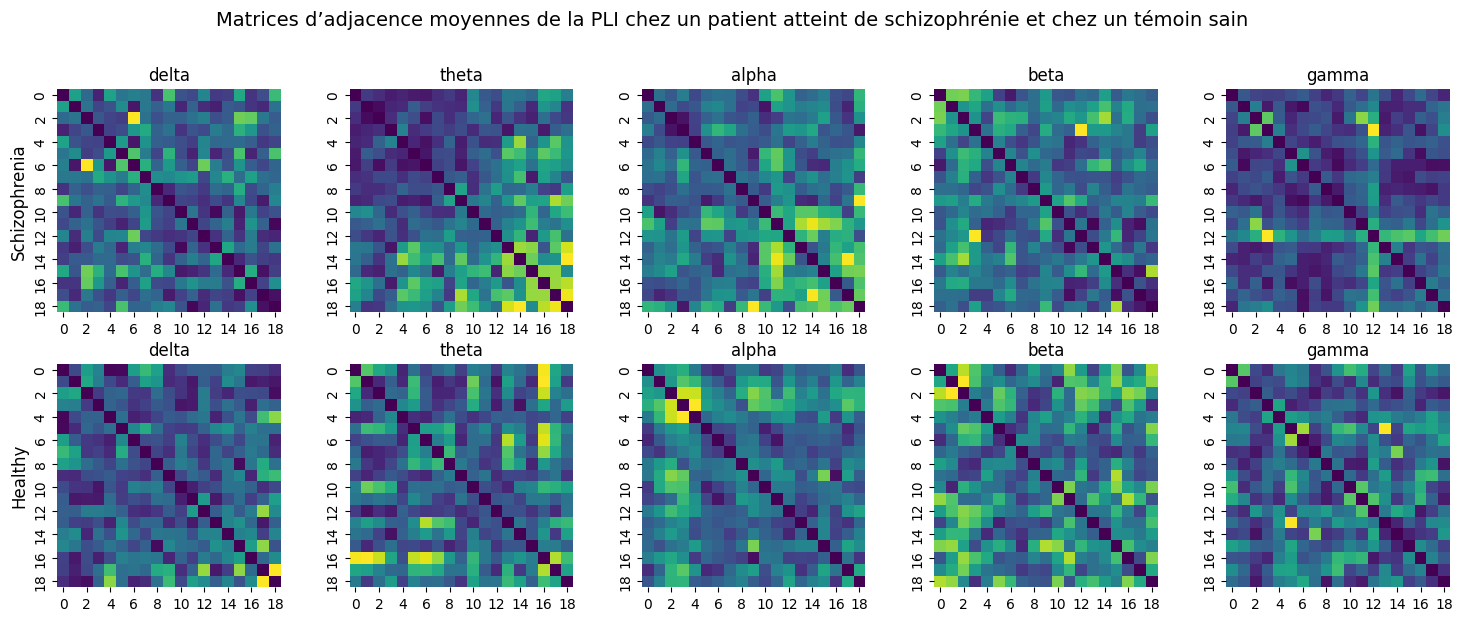

In [ ]:
def compute_pli(phases):
    n_channels, n_times = phases.shape
    pli_matrix = np.zeros((n_channels, n_channels))
    for ch1 in range(n_channels):
        for ch2 in range(n_channels):
            phase_diff = phases[ch1, :] - phases[ch2, :]
            pli_matrix[ch1, ch2] = np.abs(np.mean(np.sign(np.sin(phase_diff))))
    return pli_matrix

def process_and_plot_pli(signals, fs, group_label, ax):
    for col, (band_name, (lowcut, highcut)) in enumerate(BANDS.items()):
        # Filtrage des signaux dans la bande donnée
        filtered_signals = [
            np.array([bandpass_filter(signal[ch, :], fs, lowcut, highcut)
                      for ch in range(signal.shape[0])])
            for signal in signals
        ]

        # Calcul du PLI pour chaque signal filtré
        pli_group = np.mean(
            [compute_pli(compute_phases(filtered_signal)) for filtered_signal in filtered_signals],
            axis=0
        )

        # Affichage de la matrice moyenne pour le groupe
        sns.heatmap(pli_group, cmap="viridis", square=True, cbar=False, ax=ax[col])
        ax[col].set_title(f"{band_name}")
        if col == 0:
            ax[col].set_ylabel(group_label, fontsize=12)


# Préparer les signaux et fréquences
fs = healthy_data[0][1]
healthy_signals = [data[0] for data in healthy_data]
schizo_signals = [data[0] for data in schizo_data]

fig, axes = plt.subplots(2, len(BANDS), figsize=(15, 6))

process_and_plot_pli(schizo_signals, fs, "Schizophrenia", axes[0, :])

process_and_plot_pli(healthy_signals, fs, "Healthy", axes[1, :])

plt.suptitle("Matrices d’adjacence moyennes de la PLI chez un patient atteint de schizophrénie et chez un témoin sain",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



## Alpha-Band IMF Selection

The exploratory analysis suggests that the alpha band is particularly informative for distinguishing healthy and schizophrenia connectivity patterns.

For this reason, after EMD decomposition, we retain only the IMFs whose dominant frequency falls within the alpha range (8–13 Hz).

In [ ]:

def dominant_frequency(imf_signal, fs):
    f, Pxx = welch(imf_signal, fs=fs, nperseg=fs)
    return f[np.argmax(Pxx)]

In [ ]:

# Sélection des IMFs dans la bande alpha (8-13 Hz)
def select_alpha_imfs(imfs_array, fs, alpha_range=(8, 13)):
    n_channels, n_imf, n_times = imfs_array.shape
    alpha_imfs_list = []
    for ch in range(n_channels):
        channel_imfs = imfs_array[ch, :, :]  
        selected = []
        for i_imf in range(n_imf):
            imf_signal = channel_imfs[i_imf, :]
            freq_dom = dominant_frequency(imf_signal, fs)
            if alpha_range[0] <= freq_dom <= alpha_range[1]:
                selected.append(imf_signal)
        if len(selected) > 0:
            selected = np.array(selected)
        else:
            selected = np.empty((0, n_times))
        alpha_imfs_list.append(selected)
    max_imf_alpha = max([imfs.shape[0] for imfs in alpha_imfs_list]) if alpha_imfs_list else 0
    alpha_imfs_array = np.zeros((n_channels, max_imf_alpha, n_times))
    for i, imfs in enumerate(alpha_imfs_list):
        if imfs.size > 0:
            alpha_imfs_array[i, :imfs.shape[0], :] = imfs
    return alpha_imfs_array


In [ ]:
# Appliquer EMD et extraire les IMFs alpha
def apply_emd(signal, fs):
    imfs_all_channels = []
    for ch in range(signal.shape[0]):
        emd = EMD()
        imfs = emd(signal[ch, :])
        imfs_all_channels.append(imfs)
    max_imf = max([imfs.shape[0] for imfs in imfs_all_channels])
    imfs_array = np.zeros((signal.shape[0], max_imf, signal.shape[1]))
    for i, imfs in enumerate(imfs_all_channels):
        imfs_array[i, :imfs.shape[0], :] = imfs
    return select_alpha_imfs(imfs_array, fs, alpha_range=(8, 13))

In [ ]:
# Charger les fichiers EEG
healthy_file_paths = sorted(glob("dataverse_files/h*.edf"))
schizo_file_paths = sorted(glob("dataverse_files/s*.edf"))

# Charger les données
healthy_data = [load_eeg(file) for file in healthy_file_paths]
schizo_data = [load_eeg(file) for file in schizo_file_paths]

fs = healthy_data[0][1] if len(healthy_data) > 0 else 256
healthy_signals = [d[0] for d in healthy_data]
schizo_signals = [d[0] for d in schizo_data]

print(f"Nombre de fichiers sains : {len(healthy_signals)}")
print(f"Nombre de fichiers atteints : {len(schizo_signals)}")

Extracting EDF parameters from /content/dataverse_files/h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 236249  

In [ ]:
window_size = int(fs * 5)  # Fenêtres de 5 secondes
overlap = 0.5  # 50% de chevauchement

healthy_segments = [segment_signal(sig, window_size, overlap) for sig in healthy_signals]
schizo_segments = [segment_signal(sig, window_size, overlap) for sig in schizo_signals]

# Aplatir les segments pour les traiter par parallélisation
healthy_segments = [seg for subj in healthy_segments for seg in subj]
schizo_segments = [seg for subj in schizo_segments for seg in subj]
print(f"Nombre total de segments sains : {len(healthy_segments)}")
print(f"Nombre total de segments atteints : {len(schizo_segments)}")

Nombre total de segments sains : 5198
Nombre total de segments atteints : 6317


In [ ]:

healthy_imfs = Parallel(n_jobs=-1)(delayed(apply_emd)(seg, fs) for seg in healthy_segments)
schizo_imfs = Parallel(n_jobs=-1)(delayed(apply_emd)(seg, fs) for seg in schizo_segments)


## Instantaneous Phase Extraction

For each selected alpha IMF, the instantaneous phase is computed using the Hilbert transform.

These phase signals are then used to estimate connectivity between EEG channels.

In [ ]:
def compute_phase_matrix(imfs_array):
    if imfs_array.size == 0:
        return np.empty((0, 0, 0))  # Cas où aucune IMF n'est sélectionnée
    analytic_signal = hilbert(imfs_array, axis=2)
    phases = np.angle(analytic_signal)
    return phases

In [ ]:
healthy_phases = Parallel(n_jobs=-1)(delayed(compute_phase_matrix)(imf) for imf in healthy_imfs)
schizo_phases = Parallel(n_jobs=-1)(delayed(compute_phase_matrix)(imf) for imf in schizo_imfs)

print("Extraction et traitement terminés.")


Extraction et traitement terminés.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


## Connectivity Feature Extraction

For each segmented EEG sample, we compute two connectivity descriptors:

- PLV (Phase Locking Value)
- PLI (Phase Lag Index)

These measures are calculated across channels and across retained IMFs, then flattened and concatenated into a feature vector for classification.

In [ ]:
def compute_plv(phases):
    n_channels, n_imf, n_times = phases.shape
    plv_matrix = np.zeros((n_channels, n_channels, n_imf))
    for imf_idx in range(n_imf):
        for ch1 in range(n_channels):
            for ch2 in range(n_channels):
                phase_diff = phases[ch1, imf_idx, :] - phases[ch2, imf_idx, :]
                plv_matrix[ch1, ch2, imf_idx] = np.abs(np.mean(np.exp(1j * phase_diff)))
    return plv_matrix.flatten()

def compute_pli(phases):
    n_channels, n_imf, n_times = phases.shape
    pli_matrix = np.zeros((n_channels, n_channels, n_imf))
    for imf_idx in range(n_imf):
        for ch1 in range(n_channels):
            for ch2 in range(n_channels):
                phase_diff = phases[ch1, imf_idx, :] - phases[ch2, imf_idx, :]
                pli_matrix[ch1, ch2, imf_idx] = np.abs(np.mean(np.sign(np.sin(phase_diff))))
    return pli_matrix.flatten()


In [ ]:
def extract_features_from_phases(phases_array):
    plv_mat = compute_plv(phases_array)
    pli_mat = compute_pli(phases_array)

    plv_feat = plv_mat.flatten()
    pli_feat = pli_mat.flatten()
    features = np.concatenate([plv_feat, pli_feat])
    return features

## IMF Count Harmonization

Because EMD may produce a variable number of IMFs depending on the signal, the number of selected alpha IMFs may differ across samples.

To obtain fixed-size feature vectors, the number of retained IMFs is standardized to a maximum of three per segment.

In [ ]:
MAX_IMF = 3

def ensure_imf_count(phases_array, max_imf=MAX_IMF):
    n_channels, n_imf, n_times = phases_array.shape
    if n_imf < max_imf:
        new_array = np.zeros((n_channels, max_imf, n_times))
        new_array[:, :n_imf, :] = phases_array
        return new_array
    else:
        return phases_array[:, :max_imf, :]


## Machine Learning Classification

The extracted connectivity features are used to train and evaluate two machine learning models:

- Support Vector Machine (SVM)
- Random Forest

Performance is assessed using accuracy, classification reports, and confusion matrices.

In [ ]:
X = []
y = []

for p in healthy_phases:
    if p.size == 0:
        continue
    p_fixed = ensure_imf_count(p, MAX_IMF)
    feat = extract_features_from_phases(p_fixed)
    X.append(feat)
    y.append(0)

for p in schizo_phases:
    if p.size == 0:
        continue
    p_fixed = ensure_imf_count(p, MAX_IMF)
    feat = extract_features_from_phases(p_fixed)
    X.append(feat)
    y.append(1)


In [ ]:
X = np.array(X)
y = np.array(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.svm import SVC
clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)


from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))


print("Matrice de confusion:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       810
           1       0.86      0.78      0.82      1050

    accuracy                           0.81      1860
   macro avg       0.80      0.81      0.80      1860
weighted avg       0.81      0.81      0.81      1860

Matrice de confusion:
[[682 128]
 [233 817]]


In [ ]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Précision globale : {accuracy:.2f}")

Précision globale : 0.81


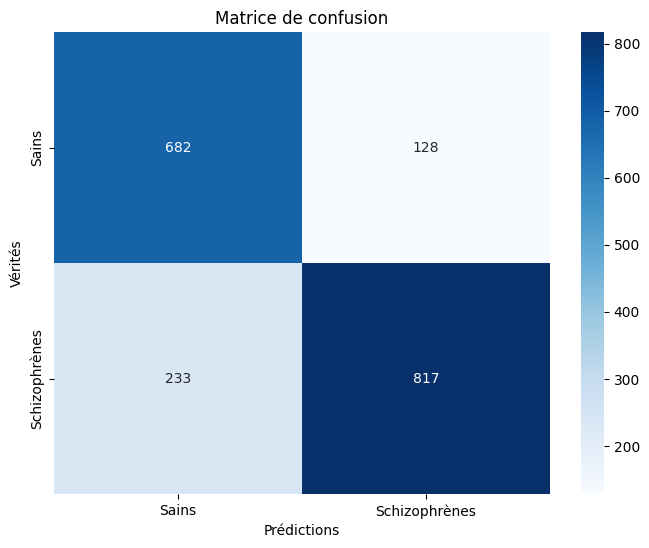

In [ ]:

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Sains", "Schizophrènes"], yticklabels=["Sains", "Schizophrènes"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion")
plt.show()


Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       810
           1       0.87      0.86      0.87      1050

    accuracy                           0.85      1860
   macro avg       0.85      0.85      0.85      1860
weighted avg       0.85      0.85      0.85      1860



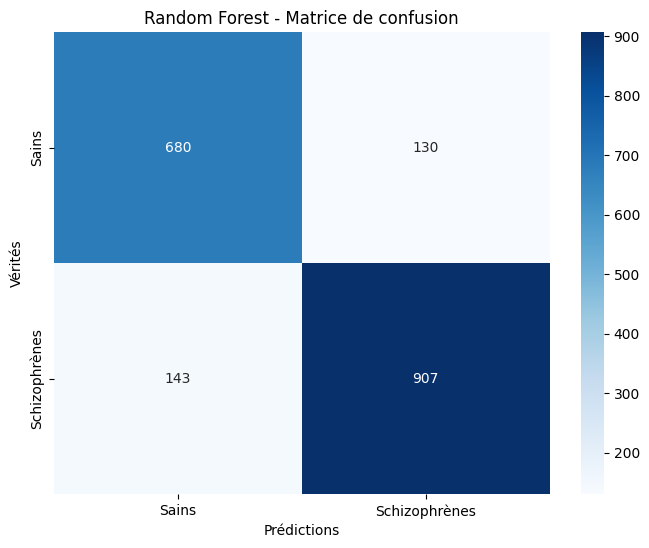

Accuracy: 0.85
Precision: 0.87
Recall: 0.86
F1 Score: 0.87


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 arbres, random_state pour reproductibilité
rf_clf.fit(X_train, y_train)


y_rf_pred = rf_clf.predict(X_test)

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_rf_pred))

conf_matrix_rf = confusion_matrix(y_test, y_rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Sains", "Schizophrènes"], yticklabels=["Sains", "Schizophrènes"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Random Forest - Matrice de confusion")
plt.show()

accuracy = accuracy_score(y_test, y_rf_pred)
precision = precision_score(y_test, y_rf_pred)
recall = recall_score(y_test, y_rf_pred)
f1 = f1_score(y_test, y_rf_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
